In [1]:
import numpy as np
import pandas as pd
from IPython.display import display
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv(
    '/Users/tomas/GitHub/ele7/data/ele7.csv',
    sep=';',
    decimal=',',
    low_memory=False
)

df.head()

,ROL_FICTICIO,DV_FICTICIO,TAMANO,TRAMO,CIIU_FINAL,GLOSA_CIIU,FE_TRANSVERSAL,FE_LONGITUDINAL,PANEL,A049,...,H084,H094,H085,H086,H087,H088,H089,H090,H091,H092
0,303008,7,1,2,G,Comercio al por mayor y al por menor; reparaci...,9.205626,0.000000,0,0,...,2,2,2,2,2,1,3,2,3,1
1,109439,5,1,2,F,Construcción,12.673940,17.982740,1,0,...,1,2,2,1,1,2,2,1,3,2
2,401684,8,3,2,L-N,Actividades de servicios (Actividades inmobili...,116.554955,105.331278,1,0,...,1,1,2,3,2,1,1,2,2,2
3,401209,5,1,2,G,Comercio al por mayor y al por menor; reparaci...,9.205626,9.177531,1,0,...,2,2,2,2,1,1,1,2,1,3
4,401278,6,3,2,F,Construcción,176.315439,125.964886,1,0,...,1,2,2,3,1,1,2,1,2,3


In [8]:
# RECODIFICACIÓN DE VARIABLES
# Normalizar nombres de columnas antes de recodificar
df.columns = df.columns.str.lower()

# Variables principales
df['tamano'] = df['tamano'].replace({
    1: 'Grande',
    2: 'Mediana',
    3: 'Pequeña 2',
    4: 'Pequeña 1',
    5: 'Micro'
})

df['tramo'] = df['tramo'].replace({
    1: 'IF',
    2: 'TA'
})

df['panel'] = df['panel'].replace({
    1: 'Panel',
    0: 'Nacimiento'
})

esc_importancia = {
    1: 'Más importante',
    2: 'Importante',
    3: 'Menos importante'
}

cols_esc_importancia = [
    'A049',
    'A050',
    'A073',
    'A051',
    'A052',
    'A053',
    'B036',
    'B037',
    'B038',
    'B039',
    'B040',
    'B041',
    'B042',
    'B043',
    'B044',
    'B082',
    'B083',
    'B084',
    'B085',
    'B086',
    'B087',
    'D149',
    'D150',
    'D151',
    'D193',
    'D153',
    'D154',
    'D155',
    'D194',
    'D195',
    'D156',
    'H093',
    'H083',
    'H084',
    'H094',
    'H085',
    'H086',
    'H087',
    'H088',
    'H089',
    'H090',
    'H091',
]
cols_esc_importancia = [col.lower() for col in cols_esc_importancia if col.lower() in df.columns]
if cols_esc_importancia:
    df[cols_esc_importancia] = df[cols_esc_importancia].replace(esc_importancia)

cols_binarias = [
    'A069', 'A070', 'A071', 'A072', 'A060', 'A0601', 'A0602',
    'A061', 'A0611', 'A0612', 'A062', 'A063', 'A064', 'A065',
    'A066', 'A067', 'A074', 'A075', 'A077', 'A079', 'A082',
    'A0821', 'A083', 'A085', 'B001', 'B002', 'B003', 'B004',
    'B005', 'B006', 'B007', 'B008', 'B010', 'B011', 'B012',
    'B013', 'B014', 'B015', 'B016', 'B017', 'B018', 'B019',
    'B020', 'B104', 'B105', 'B022', 'B023', 'B024', 'B025',
    'B026', 'B027', 'B028', 'B029', 'B030', 'B031', 'B032',
    'B033', 'B034', 'B035', 'B106', 'B1061', 'B045', 'B046',
    'B047', 'B048', 'B049', 'B050', 'B051', 'B052', 'B053',
    'B054', 'B055', 'B056', 'B058', 'B059', 'B061', 'B062',
    'B063', 'B064', 'B067', 'B068', 'B069', 'B070', 'B071',
    'B072', 'B073', 'B074', 'B075', 'B076', 'B077', 'B078',
    'B079', 'B080', 'B081', 'B088', 'B089', 'B090', 'B091',
    'B092', 'B093', 'B094', 'B095', 'B096', 'B097', 'B098',
    'B099', 'B100', 'B101', 'B102', 'D1103', 'D1104', 'D1303',
    'D1304', 'D1601', 'D1602', 'D1501', 'D1502', 'D1503',
    'D1504', 'D1505', 'D1506', 'C109', 'C1094', 'C1091',
    'C1092', 'C1093', 'C164', 'C1641', 'C165', 'C166', 'C167',
    'C168', 'C169', 'C170', 'C171', 'I005', 'I006', 'I007',
    'I050', 'I051', 'I066', 'I067', 'I068', 'I069', 'I070',
    'I071', 'I072', 'I073', 'I074', 'I111', 'I112', 'I113',
    'I114', 'I115', 'I116', 'I117', 'I118', 'I119', 'D157',
    'D159', 'D161', 'D158', 'D160', 'D162', 'D196', 'D197',
    'D198', 'D199', 'D200', 'D201', 'D020', 'D021', 'D022',
    'D023', 'D024', 'D025', 'D026', 'D027', 'D028', 'D029',
    'D030', 'D031', 'D033', 'D034', 'D035', 'D036', 'D037',
    'D038', 'D039', 'D040', 'D041', 'D042', 'D043', 'D044',
    'D163', 'D164', 'D165', 'D166', 'D167', 'D168', 'D178',
    'D179', 'D180', 'D136', 'D137', 'D062', 'D063', 'D064',
    'D065', 'D066', 'D072', 'D073', 'D074', 'D075', 'D076',
    'D082', 'D083', 'D084', 'D085', 'D086', 'D087', 'D088',
    'D089', 'D090', 'D091', 'D092', 'D093', 'D094', 'D095',
    'D096', 'D097', 'D098', 'D169', 'D170', 'D171', 'D172',
    'D173', 'D174', 'D175', 'D176', 'D177', 'D099', 'D100',
    'D101', 'D102', 'D103', 'D104', 'D105', 'D106', 'D107'
]
cols_binarias = [col.lower() for col in cols_binarias if col.lower() in df.columns]
if cols_binarias:
    df[cols_binarias] = df[cols_binarias].replace({
        1: 'Marca esta opción',
        0: 'No marca esta opción'
    })

cols_frecuencia = ['D014', 'D015', 'D016', 'D017', 'D018', 'D019']
cols_frecuencia = [col.lower() for col in cols_frecuencia if col.lower() in df.columns]
if cols_frecuencia:
    df[cols_frecuencia] = df[cols_frecuencia].replace({
        1: 'Siempre',
        2: 'Muchas veces',
        3: 'Pocas veces',
        4: 'Nunca',
        5: 'No sabe'
    })

df['ciiu_final'] = df['ciiu_final'].replace({
    'A': 'Agricultura, ganadería, silvicultura y pesca',
    'B': 'Explotación de minas y canteras',
    'C': 'Industrias manufactureras',
    'D-E': 'Suministro de electricidad, gas y agua',
    'F': 'Construcción',
    'G': 'Comercio al por mayor y al por menor',
    'H': 'Transporte y almacenamiento',
    'I': 'Actividades de alojamiento y de servicio de comidas',
    'J': 'Información y comunicaciones',
    'K': 'Actividades financieras y de seguros',
    'L-N': 'Actividades de servicios',
    'M': 'Actividades profesionales, científicas y técnicas',
    'R-S': 'Otros servicios',
})

pd.options.display.float_format = '{:,.2f}'.format

df.head()

,rol_ficticio,dv_ficticio,tamano,tramo,ciiu_final,glosa_ciiu,fe_transversal,fe_longitudinal,panel,a049,...,h084,h094,h085,h086,h087,h088,h089,h090,h091,h092
0,303008,7,Grande,TA,Comercio al por mayor y al por menor,Comercio al por mayor y al por menor; reparaci...,9.21,0.00,Nacimiento,0,...,Importante,Importante,Importante,Importante,Importante,Más importante,Menos importante,Importante,Menos importante,1
1,109439,5,Grande,TA,Construcción,Construcción,12.67,17.98,Panel,0,...,Más importante,Importante,Importante,Más importante,Más importante,Importante,Importante,Más importante,Menos importante,2
2,401684,8,Pequeña 2,TA,Actividades de servicios,Actividades de servicios (Actividades inmobili...,116.55,105.33,Panel,0,...,Más importante,Más importante,Importante,Menos importante,Importante,Más importante,Más importante,Importante,Importante,2
3,401209,5,Grande,TA,Comercio al por mayor y al por menor,Comercio al por mayor y al por menor; reparaci...,9.21,9.18,Panel,0,...,Importante,Importante,Importante,Importante,Más importante,Más importante,Más importante,Importante,Más importante,3
4,401278,6,Pequeña 2,TA,Construcción,Construcción,176.32,125.96,Panel,0,...,Más importante,Importante,Importante,Menos importante,Más importante,Más importante,Importante,Más importante,Importante,3


In [ ]:
# MUESTRA LONGITUDINAL
if isinstance(df, pd.DataFrame):
    df_longitudinal = df[df['panel'] == 'Panel'].copy()
    df_longitudinal


,rol_ficticio,dv_ficticio,tamano,tramo,ciiu_final,glosa_ciiu,fe_transversal,fe_longitudinal,panel,a049,...,h084,h094,h085,h086,h087,h088,h089,h090,h091,h092
1,109439,5,Grande,TA,Construcción,Construcción,12.67,17.98,Panel,0,...,Más importante,Importante,Importante,Más importante,Más importante,Importante,Importante,Más importante,Menos importante,2
2,401684,8,Pequeña 2,TA,Actividades de servicios,Actividades de servicios (Actividades inmobili...,116.55,105.33,Panel,0,...,Más importante,Más importante,Importante,Menos importante,Importante,Más importante,Más importante,Importante,Importante,2
3,401209,5,Grande,TA,Comercio al por mayor y al por menor,Comercio al por mayor y al por menor; reparaci...,9.21,9.18,Panel,0,...,Importante,Importante,Importante,Importante,Más importante,Más importante,Más importante,Importante,Más importante,3
4,401278,6,Pequeña 2,TA,Construcción,Construcción,176.32,125.96,Panel,0,...,Más importante,Importante,Importante,Menos importante,Más importante,Más importante,Importante,Más importante,Importante,3
5,401691,5,Grande,TA,Información y comunicaciones,Información y comunicaciones,6.44,9.47,Panel,0,...,Más importante,Menos importante,Menos importante,Menos importante,Menos importante,Menos importante,Menos importante,Importante,Menos importante,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6587,500242,5,Pequeña 1,TA,Industrias manufactureras,Industrias manufactureras,112.08,83.80,Panel,0,...,Importante,Más importante,Menos importante,Menos importante,Menos importante,Más importante,Menos importante,Menos importante,Menos importante,3
6588,402476,6,Grande,TA,Explotación de minas y canteras,Explotación de minas y canteras,5.66,8.75,Panel,Más importante,...,Importante,Importante,Importante,Importante,Importante,Importante,Importante,Importante,Importante,2
6589,401671,8,Mediana,TA,Comercio al por mayor y al por menor,Comercio al por mayor y al por menor; reparaci...,71.17,65.07,Panel,0,...,Más importante,Más importante,Más importante,Importante,Más importante,Más importante,Importante,Importante,Más importante,1
6590,401804,1,Pequeña 2,TA,"Agricultura, ganadería, silvicultura y pesca","Agricultura, ganadería, silvicultura y pesca",140.95,129.58,Panel,Más importante,...,Más importante,Más importante,Más importante,Importante,Más importante,Importante,Importante,Importante,Importante,2


In [ ]:
# FUNCION PARA ESTADÍSTICAS DESCRIPTIVAS PONDERADAS
def dstats(data_df, variables, tipo='frecuencia', variable_cruce=None, factor=None, transponer=False):
    """
    Realiza análisis ponderados para la ENUPE 2022.

    Parámetros:
    -----------
    data_df : DataFrame con los datos
    variables : str o lista de str con el nombre de la(s) variable(s)
    tipo : 'frecuencia', 'cruzada' o 'promedio'
    variable_cruce : str con la variable de cruce (solo para tipo='cruzada')
    factor : nombre de la columna del factor de expansión (default: 'exp')

    Ejemplos:
    ---------
    dstats(df, 'sexo_label', tipo='frecuencia')
    dstats(df, 'sexo_label', tipo='cruzada', variable_cruce='macrozona_label')
    dstats(df, ['edad', 'ingresos'], tipo='promedio')
    dstats(df, ['d1204', 'd1205'], tipo='promedio', variable_cruce='tamano', factor='fe_transversal')
    """
    if not isinstance(data_df, pd.DataFrame):
        return None

    # --- Validaciones ---
    if isinstance(variables, str):
        variables = [variables]

    columnas_necesarias = variables + [factor]
    if variable_cruce:
        columnas_necesarias.append(variable_cruce)

    for col_necesaria in columnas_necesarias:
        if col_necesaria not in data_df.columns:
            raise ValueError(f"La columna '{col_necesaria}' no existe en el DataFrame.")

    # --- Frecuencia ponderada ---
    if tipo == 'frecuencia':
        var = variables[0]
        total_pond = data_df[factor].sum()

        resultado = (
            data_df.groupby(var, observed=True)[factor]
            .sum()
            .reset_index()
            .rename(columns={factor: 'n_ponderado'})
        )
        resultado['porcentaje'] = (resultado['n_ponderado'] / total_pond * 100).round(2)
        resultado = resultado.sort_values('n_ponderado', ascending=False).reset_index(drop=True)

        fila_totales = pd.DataFrame({
            var: ['Total'],
            'n_ponderado': [resultado['n_ponderado'].sum()],
            'porcentaje': [resultado['porcentaje'].sum().round(2)]
        })

        resultado = pd.concat([resultado, fila_totales], ignore_index=True)
        return resultado

    # --- Tabla cruzada ponderada ---
    elif tipo == 'cruzada':
        if not variable_cruce:
            raise ValueError("Debes especificar 'variable_cruce' para tipo='cruzada'.")
        var = variables[0]

        tabla = data_df.pivot_table(
            values=factor,
            index=var,
            columns=variable_cruce,
            aggfunc='sum',
            fill_value=0,
            observed=False
        )

        tabla_pct = tabla.div(tabla.sum(axis=0), axis=1).mul(100).round(2)

        if transponer:
            tabla = tabla.T
            tabla_pct = tabla_pct.T

        tabla.loc['Total'] = tabla.sum(numeric_only=True)
        tabla_pct.loc['Total'] = tabla_pct.sum(numeric_only=True).round(2)

        display(tabla_pct)
        display(tabla)
        return tabla

    # --- Promedio ponderado ---
    elif tipo == 'promedio':

        # Sin cruce: comportamiento original
        if not variable_cruce:
            resultados = {}
            for var in variables:
                datos = data_df[[var, factor]].dropna()
                promedio = np.average(datos[var], weights=datos[factor])
                resultados[var] = float(round(promedio, 4))

            resultado_df = pd.DataFrame(
                list(resultados.items()),
                columns=['variable', 'promedio_ponderado']
            )
            return resultado_df

        # Con cruce: promedio ponderado por grupo
        else:
            filas = {}

            for grupo, subdf in data_df.groupby(variable_cruce, observed=True):
                fila = {}
                for var in variables:
                    datos = subdf[[var, factor]].dropna()
                    if len(datos) == 0 or datos[factor].sum() == 0:
                        fila[var] = np.nan
                    else:
                        fila[var] = float(round(np.average(datos[var], weights=datos[factor]), 4))
                filas[grupo] = fila

            # Fila Total sobre todo el df
            fila_total = {}
            for var in variables:
                datos = data_df[[var, factor]].dropna()
                fila_total[var] = float(round(np.average(datos[var], weights=datos[factor]), 4))
            filas['Total'] = fila_total

            resultado_df = pd.DataFrame(filas).T
            resultado_df.index.name = variable_cruce
            
            return resultado_df

        # --- Suma ponderada ---
    elif tipo == 'suma':

        # Sin cruce: suma ponderada total
        if not variable_cruce:
            resultados = {}
            for var in variables:
                datos = data_df[[var, factor]].dropna()
                # Cada valor se multiplica por su peso y se suman
                resultados[var] = float(round((datos[var] * datos[factor]).sum(), 4))

            resultado_df = pd.DataFrame(
                list(resultados.items()),
                columns=['variable', 'suma_ponderada']
            )
            return resultado_df

        # Con cruce: suma ponderada por grupo
        else:
            filas = {}

            for grupo, subdf in data_df.groupby(variable_cruce, observed=True):
                fila = {}
                for var in variables:
                    datos = subdf[[var, factor]].dropna()
                    fila[var] = float(round((datos[var] * datos[factor]).sum(), 4))
                filas[grupo] = fila

            # Fila Total sobre todo el df
            fila_total = {}
            for var in variables:
                datos = data_df[[var, factor]].dropna()
                fila_total[var] = float(round((datos[var] * datos[factor]).sum(), 4))
            filas['Total'] = fila_total

            resultado_df = pd.DataFrame(filas).T
            resultado_df.index.name = variable_cruce
            return resultado_df

    else:
        raise ValueError("El parámetro 'tipo' debe ser 'frecuencia', 'cruzada' o 'promedio'.")

In [ ]:
inversion_pcs = dstats(df, 'tamano', tipo='cruzada', variable_cruce='b092', transponer=False, factor='fe_transversal')
display(inversion_pcs)

inversion_sw = dstats(df, 'tamano', tipo='cruzada', variable_cruce='b093', transponer=False, factor='fe_transversal')
display(inversion_sw)

inversion_otros = dstats(df, 'tamano', tipo='cruzada', variable_cruce='b094', transponer=False, factor='fe_transversal')
display(inversion_otros)

b092,Marca esta opción,No marca esta opción
tamano,,
Grande,12.46,2.10
Mediana,16.96,6.03
Micro,18.61,45.57
Pequeña 1,15.71,22.60
Pequeña 2,36.26,23.70
Total,100.00,100.00


b092,Marca esta opción,No marca esta opción
tamano,,
Grande,"5,828.23","7,619.38"
Mediana,"7,934.09","21,876.62"
Micro,"8,708.23","165,182.96"
Pequeña 1,"7,352.04","81,924.83"
Pequeña 2,"16,962.59","85,910.85"
Total,"46,785.19","362,514.63"


b093,Marca esta opción,No marca esta opción
tamano,,
Grande,13.05,2.78
Mediana,19.10,6.68
Micro,20.09,43.64
Pequeña 1,17.19,22.05
Pequeña 2,30.57,24.85
Total,100.00,100.00


b093,Marca esta opción,No marca esta opción
tamano,,
Grande,"2,613.08","10,834.53"
Mediana,"3,824.18","25,986.54"
Micro,"4,021.37","169,869.82"
Pequeña 1,"3,441.53","85,835.34"
Pequeña 2,"6,119.51","96,753.93"
Total,"20,019.67","389,280.15"


b094,Marca esta opción,No marca esta opción
tamano,,
Grande,6.06,3.21
Mediana,14.68,7.09
Micro,46.71,42.37
Pequeña 1,9.17,22.14
Pequeña 2,23.38,25.18
Total,100.00,99.99


b094,Marca esta opción,No marca esta opción
tamano,,
Grande,631.99,"12,815.62"
Mediana,"1,531.00","28,279.72"
Micro,"4,869.88","169,021.32"
Pequeña 1,955.66,"88,321.21"
Pequeña 2,"2,438.02","100,435.42"
Total,"10,426.54","398,873.28"


In [ ]:
dstats_resultado = dstats(df, 'tamano', tipo='cruzada', variable_cruce='d1103', transponer=False, factor='fe_transversal')
display(dstats_resultado)

d1103,Marca esta opción,No marca esta opción
tamano,,
Grande,6.81,3.06
Mediana,7.11,7.29
Micro,25.35,43.57
Pequeña 1,32.42,21.14
Pequeña 2,28.30,24.93
Total,99.99,99.99


d1103,Marca esta opción,No marca esta opción
tamano,,
Grande,"1,655.94","11,791.66"
Mediana,"1,728.98","28,081.73"
Micro,"6,160.25","167,730.95"
Pequeña 1,"7,880.39","81,396.48"
Pequeña 2,"6,878.72","95,994.72"
Total,"24,304.28","384,995.54"


,2020,2021,2022
tamano,,,
Grande,"10,006,640,066","13,754,121,146","14,705,819,963"
Mediana,"486,149,949","1,310,281,864","1,015,653,376"
Micro,"90,635,891","121,924,010","147,512,274"
Pequeña 1,"161,591,539","340,464,456","434,877,889"
Pequeña 2,"821,985,746","1,516,531,615","1,363,060,019"
Total,"11,567,003,191","17,043,323,091","17,666,923,519"


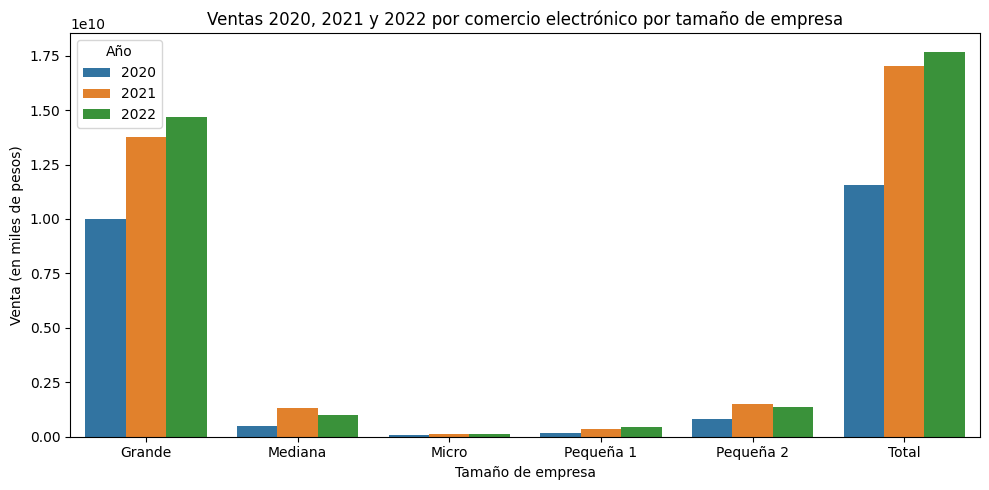

In [ ]:
ventas_ecom = dstats(df, ['d1204', 'd1205', 'd1208'], tipo='suma', variable_cruce='tamano', factor='fe_transversal')

if ventas_ecom is not None and isinstance(ventas_ecom, pd.DataFrame):
    display(ventas_ecom)

    display(
        ventas_ecom.rename(columns={'d1204': '2020', 'd1205': '2021', 'd1208': '2022'})
        .style.set_caption("Ventas 2020, 2021 y 2022 por comercio electrónico por tamaño de empresa (en miles de pesos)")
        .format("{:,.0f}")
    )

    # Preparar datos: seaborn necesita formato "largo" (una fila por observación)
    ventas_ecom_plot = (
        ventas_ecom.rename(columns={'d1204': '2020', 'd1205': '2021', 'd1208': '2022'})
        .reset_index()  # convierte el índice 'tamano' en columna
        .melt(id_vars='tamano', var_name='año', value_name='venta')  # formato largo
    )

    # Graficar
    fig, ax = plt.subplots(figsize=(10, 5))

    sns.barplot(
        data=ventas_ecom_plot,
        x='tamano',
        y='venta',
        hue='año',
        ax=ax
    )

    ax.set_title("Ventas 2020, 2021 y 2022 por comercio electrónico por tamaño de empresa")
    ax.set_xlabel("Tamaño de empresa")
    ax.set_ylabel("Venta (en miles de pesos)")
    ax.legend(title='Año')

    plt.tight_layout()
    plt.show()

,2020,2021,2022
tamano,,,
Grande,"3,206,661,003","3,305,299,158","3,641,108,629"
Mediana,"30,734,859","36,686,905","39,564,743"
Micro,"11,028,919","13,099,615","18,676,550"
Pequeña 1,"60,041,851","72,842,356","58,453,465"
Pequeña 2,"22,046,711","30,852,860","36,482,733"
Total,"3,330,513,343","3,458,780,894","3,794,286,121"


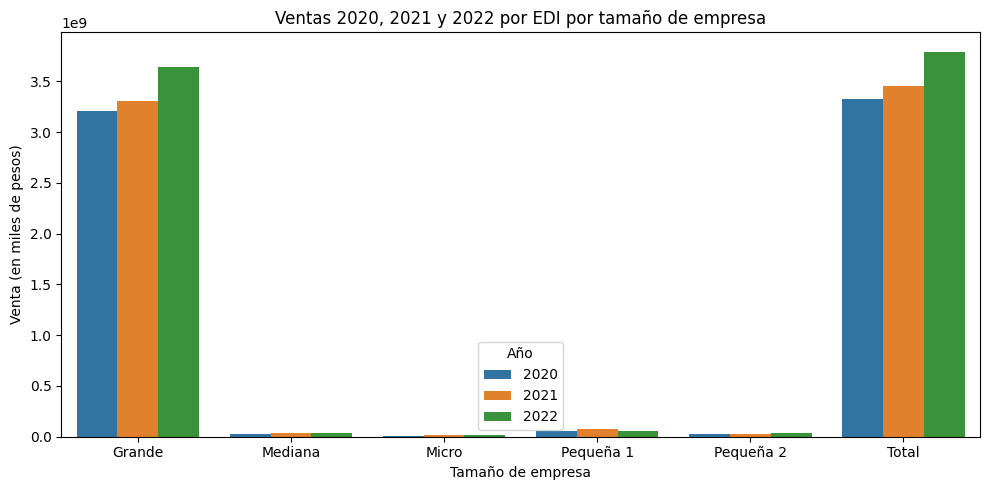

In [ ]:
ventas_edi = dstats(df, ['d1206', 'd1207', 'd1209'], tipo='suma', variable_cruce='tamano', factor='fe_transversal')

if ventas_edi is not None and isinstance(ventas_edi, pd.DataFrame):
    display(ventas_edi)

    display(
        ventas_edi.rename(columns={'d1206': '2020', 'd1207': '2021', 'd1209': '2022'})
        .style.set_caption("Ventas 2020, 2021 y 2022 por EDI por tamaño de empresa (en miles de pesos)")
        .format("{:,.0f}")
    )

    # Preparar datos: seaborn necesita formato "largo" (una fila por observación)
    ventas_edi_plot = (
        ventas_edi.rename(columns={'d1206': '2020', 'd1207': '2021', 'd1209': '2022'})
        .reset_index()  # convierte el índice 'tamano' en columna
        .melt(id_vars='tamano', var_name='año', value_name='venta')  # formato largo
    )

    # Graficar
    fig, ax = plt.subplots(figsize=(10, 5))

    sns.barplot(
        data=ventas_edi_plot,
        x='tamano',
        y='venta',
        hue='año',
        ax=ax
    )

    ax.set_title("Ventas 2020, 2021 y 2022 por EDI por tamaño de empresa")
    ax.set_xlabel("Tamaño de empresa")
    ax.set_ylabel("Venta (en miles de pesos)")
    ax.legend(title='Año')

    plt.tight_layout()
    plt.show()

,2020,2021,2022
tamano,,,
Grande,"2,020,870,216","3,328,814,473","4,445,391,485"
Mediana,"158,144,033","251,707,494","175,547,954"
Micro,"10,813,305","27,043,882","423,501,267"
Pequeña 1,"61,793,736,197","30,136,138","78,902,274"
Pequeña 2,"194,492,586","271,230,042","747,430,400"
Total,"64,178,056,336","3,908,932,030","5,870,773,380"


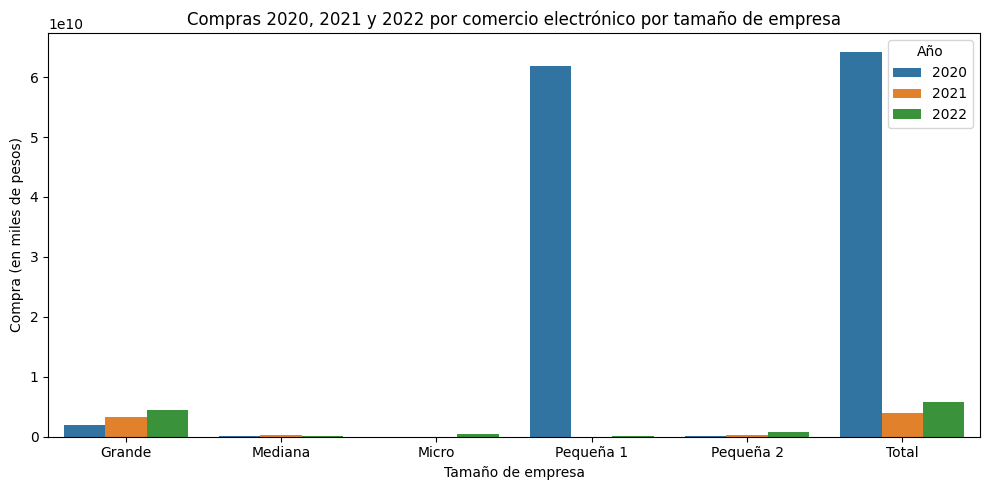

In [ ]:
compras_ecom = dstats(df, ['d1404', 'd1405', 'd1408'], tipo='suma', variable_cruce='tamano', factor='fe_transversal')

if compras_ecom is not None and isinstance(compras_ecom, pd.DataFrame):
    display(compras_ecom)

    display(
        compras_ecom.rename(columns={'d1404': '2020', 'd1405': '2021', 'd1408': '2022'})
        .style.set_caption("Compras 2020, 2021 y 2022 por comercio electrónico por tamaño de empresa (en miles de pesos)")
        .format("{:,.0f}")
    )

    # Preparar datos: seaborn necesita formato "largo" (una fila por observación)
    compras_ecom_plot = (
        compras_ecom.rename(columns={'d1404': '2020', 'd1405': '2021', 'd1408': '2022'})
        .reset_index()  # convierte el índice 'tamano' en columna
        .melt(id_vars='tamano', var_name='año', value_name='compra')  # formato largo
    )

    # Graficar
    fig, ax = plt.subplots(figsize=(10, 5))

    sns.barplot(
        data=compras_ecom_plot,
        x='tamano',
        y='compra',
        hue='año',
        ax=ax
    )

    ax.set_title("Compras 2020, 2021 y 2022 por comercio electrónico por tamaño de empresa")
    ax.set_xlabel("Tamaño de empresa")
    ax.set_ylabel("Compra (en miles de pesos)")
    ax.legend(title='Año')

    plt.tight_layout()
    plt.show()

,2020,2021,2022
tamano,,,
Grande,"427,523,087","1,033,269,324","823,832,017"
Mediana,"8,184,634","11,338,659","10,306,287"
Micro,"648,987","734,137","2,050,747"
Pequeña 1,"14,995,564","18,078,827","14,747,826"
Pequeña 2,"166,752,281","270,157,707","68,765,538"
Total,"618,104,553","1,333,578,654","919,702,415"


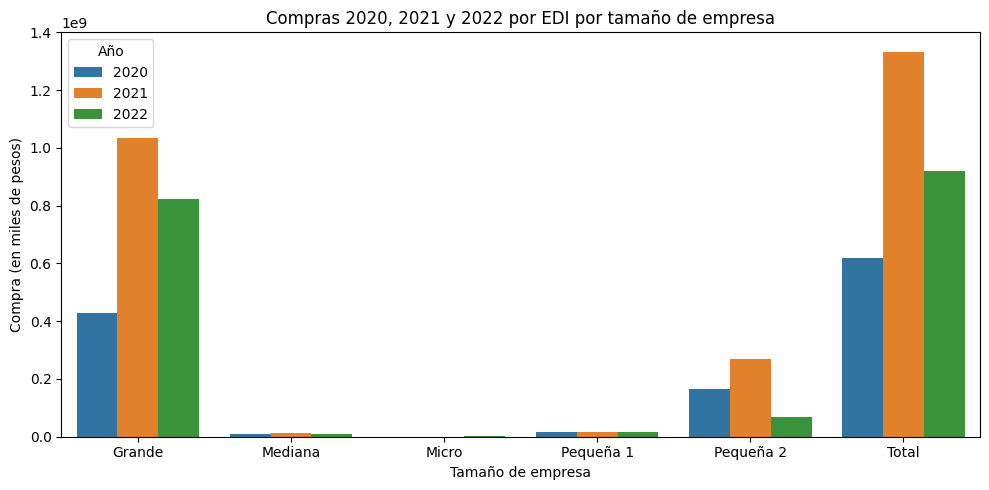

In [ ]:
compras_edi = dstats(df, ['d1406', 'd1407', 'd1409'], tipo='suma', variable_cruce='tamano', factor='fe_transversal')

if compras_edi is not None and isinstance(compras_edi, pd.DataFrame):
    display(compras_edi)

    display(
        compras_edi.rename(columns={'d1406': '2020', 'd1407': '2021', 'd1409': '2022'})
        .style.set_caption("Compras 2020, 2021 y 2022 por EDI por tamaño de empresa (en miles de pesos)")
        .format("{:,.0f}")
    )

    # Preparar datos: seaborn necesita formato "largo" (una fila por observación)
    compras_edi_plot = (
        compras_edi.rename(columns={'d1406': '2020', 'd1407': '2021', 'd1409': '2022'})
        .reset_index()  # convierte el índice 'tamano' en columna
        .melt(id_vars='tamano', var_name='año', value_name='compra')  # formato largo
    )

    # Graficar
    fig, ax = plt.subplots(figsize=(10, 5))

    sns.barplot(
        data=compras_edi_plot,
        x='tamano',
        y='compra',
        hue='año',
        ax=ax
    )

    ax.set_title("Compras 2020, 2021 y 2022 por EDI por tamaño de empresa")
    ax.set_xlabel("Tamaño de empresa")
    ax.set_ylabel("Compra (en miles de pesos)")
    ax.legend(title='Año')

    plt.tight_layout()
    plt.show()

,2020,2021,2022
tamano,,,
Grande,"1,909,485,448","2,035,125,266","2,285,426,339"
Mediana,"216,094,705","256,367,483","267,137,557"
Micro,"248,536,621","311,135,548","268,939,631"
Pequeña 1,"32,013,076","40,463,600","33,581,000"
Pequeña 2,"153,504,641","175,894,199","177,901,849"
Total,"2,559,634,491","2,818,986,096","3,032,986,377"


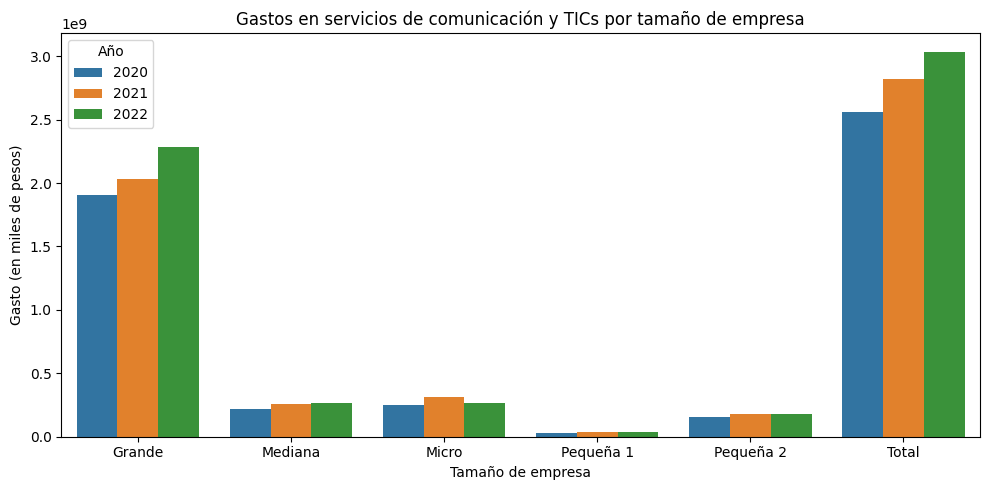

In [ ]:
gasto_tic = dstats(df, ['c009', 'c045', 'c081'], tipo='suma', variable_cruce='tamano', factor='fe_transversal')

if gasto_tic is not None and isinstance(gasto_tic, pd.DataFrame):
    display(gasto_tic)

    display(
        gasto_tic.rename(columns={'c009': '2020', 'c045': '2021', 'c081': '2022'})
        .style.set_caption("Gastos en servicios de comunicación y TICs por tamaño de empresa (en miles de pesos)")
        .format("{:,.0f}")
    )

    # Preparar datos: seaborn necesita formato "largo" (una fila por observación)
    gasto_tic_plot = (
        gasto_tic.rename(columns={'c009': '2020', 'c045': '2021', 'c081': '2022'})
        .reset_index()  # convierte el índice 'tamano' en columna
        .melt(id_vars='tamano', var_name='año', value_name='gasto')  # formato largo
    )

    # Graficar
    fig, ax = plt.subplots(figsize=(10, 5))

    sns.barplot(
        data=gasto_tic_plot,
        x='tamano',
        y='gasto',
        hue='año',
        ax=ax
    )

    ax.set_title("Gastos en servicios de comunicación y TICs por tamaño de empresa")
    ax.set_xlabel("Tamaño de empresa")
    ax.set_ylabel("Gasto (en miles de pesos)")
    ax.legend(title='Año')

    plt.tight_layout()
    plt.show()

In [ ]:
if isinstance(df, pd.DataFrame):
    df.info()